In [1]:
# Cell 1: Downloading Dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("briscdataset/brisc2025")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/datasets/briscdataset/brisc2025


In [2]:
# Cell 2: Defining Path, Imports and Environment Setup

# Kaggle-safe package bootstrap
import sys
import subprocess
import pkgutil

def _pip_install(pkg: str):
    print(f"[pip] Installing: {pkg}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

if pkgutil.find_loader("segmentation_models_pytorch") is None:
    _pip_install("segmentation-models-pytorch")

if pkgutil.find_loader("albumentations") is None:
    _pip_install("albumentations")

# OpenCV is typically present on Kaggle; install headless only if missing
if pkgutil.find_loader("cv2") is None:
    _pip_install("opencv-python-headless")


# Required imports
import os
import glob
import copy
import gc
import random
import warnings
from itertools import cycle

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    roc_curve,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import segmentation_models_pytorch as smp

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# Use GPU on Kaggle when available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# CPU / OpenCV hygiene
try:
    cv2.setNumThreads(0)
except Exception:
    pass

try:
    torch.set_num_threads(max(1, min(4, os.cpu_count() or 2)))
except Exception:
    pass

gc.collect()


[pip] Installing: segmentation-models-pytorch


/tmp/ipykernel_23/1762211475.py:12: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("segmentation_models_pytorch") is None:


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.2 MB/s eta 0:00:00


/tmp/ipykernel_23/1762211475.py:15: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("albumentations") is None:
/tmp/ipykernel_23/1762211475.py:19: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("cv2") is None:


Using device: cuda


0

In [3]:
# Cell 3: Preparing DataFrames for Segmentation and Classification

from IPython.display import display

print("\n--- Starting Data Preparation (Corrected Logic, KaggleHub-aware) ---")

# Parse the downloaded dataset path from kagglehub
dataset_root = path
if os.path.exists(os.path.join(dataset_root, "brisc2025")):
    base_path = os.path.join(dataset_root, "brisc2025")
else:
    base_path = dataset_root

print("Using base path:", base_path)

# Expected BRISC 2025 folder structure
segmentation_train_path = os.path.join(base_path, "segmentation_task", "train")
classification_train_path = os.path.join(base_path, "classification_task", "train")

assert os.path.isdir(classification_train_path), f"Classification train folder not found: {classification_train_path}"

IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def list_image_files(folder: str):
    files = []
    for ext in IMAGE_EXTS:
        files.extend(glob.glob(os.path.join(folder, f"*{ext}")))
    return sorted(files)

def stem_id(fp: str) -> str:
    return os.path.splitext(os.path.basename(fp))[0]

def normalize_mask_id(stem: str) -> str:
    # Some datasets name masks like "xxx_mask" or "xxx-mask"
    for suf in ["_mask", "-mask", " mask"]:
        if stem.endswith(suf):
            return stem[: -len(suf)]
    return stem

# --- 1) MASTER Classification DataFrame (source of truth: image_path + label) ---
class_image_paths = []
class_labels = []

label_folders = [d for d in os.listdir(classification_train_path) if os.path.isdir(os.path.join(classification_train_path, d))]
label_folders = sorted(label_folders)

for label_name in label_folders:
    label_dir = os.path.join(classification_train_path, label_name)
    img_files = list_image_files(label_dir)
    for fp in img_files:
        class_image_paths.append(fp)
        class_labels.append(label_name)

master_df = pd.DataFrame({
    "image_path": class_image_paths,
    "label": class_labels,
})
master_df["image_id"] = master_df["image_path"].apply(stem_id)

print(f"Found {len(master_df)} total images in the classification training set.")
print("master_df head:")
display(master_df.head())

# --- 2) Segmentation (Mask) DataFrame (only contains paths to available masks) ---
seg_images_path = os.path.join(segmentation_train_path, "images")
seg_masks_path  = os.path.join(segmentation_train_path, "masks")

if os.path.isdir(seg_images_path) and os.path.isdir(seg_masks_path):
    seg_image_files = list_image_files(seg_images_path)
    seg_mask_files  = list_image_files(seg_masks_path)

    # Build a mask map by ID (normalize in case of suffixes)
    mask_map = {}
    for mfp in seg_mask_files:
        mid = normalize_mask_id(stem_id(mfp))
        # keep first occurrence if duplicates exist
        if mid not in mask_map:
            mask_map[mid] = mfp

    mask_rows = []
    for ifp in seg_image_files:
        iid = stem_id(ifp)
        if iid in mask_map:
            mask_rows.append((iid, mask_map[iid]))

    mask_df = pd.DataFrame(mask_rows, columns=["image_id", "mask_path"])
    print(f"Found {len(mask_df)} corresponding masks in the segmentation training set.")
else:
    mask_df = pd.DataFrame(columns=["image_id", "mask_path"])
    print("Segmentation task folders not found, proceeding without masks.")

# --- 3) Merge with LEFT JOIN (keeps all images, masks only where they exist) ---
final_df = pd.merge(master_df, mask_df, on="image_id", how="left")

# Map text labels to integers (stable ordering)
unique_labels = sorted(final_df["label"].unique())
label_map = {lbl: i for i, lbl in enumerate(unique_labels)}
final_df["label_idx"] = final_df["label"].map(label_map).astype(int)

# Optional: also store a binary "tumor present" label (useful later)
no_tumor_aliases = {"no_tumor", "no-tumor", "no tumor", "healthy", "normal", "nt"}
final_df["tumor_present"] = (~final_df["label"].str.lower().isin(no_tumor_aliases)).astype(int)

print("\nMerged DataFrame created successfully with LEFT join.")
print("final_df head:")
display(final_df.head())
print("\nLabel mapping:")
print(label_map)

# --- Train / Validation / Test Split: 70% / 15% / 15% (STRATIFIED) ---
train_df, temp_df = train_test_split(
    final_df,
    test_size=0.30,
    random_state=SEED,
    stratify=final_df["label_idx"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # half of 30% => 15%
    random_state=SEED,
    stratify=temp_df["label_idx"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(final_df):.1%})")
print(f"  Val:   {len(val_df)} ({len(val_df)/len(final_df):.1%})")
print(f"  Test:  {len(test_df)} ({len(test_df)/len(final_df):.1%})")

print("\nTrain label distribution:")
print(train_df["label"].value_counts())


--- Starting Data Preparation (Corrected Logic, KaggleHub-aware) ---
Using base path: /kaggle/input/datasets/briscdataset/brisc2025/brisc2025
Found 5000 total images in the classification training set.
master_df head:


,image_path,label,image_id
0,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00001_gl_ax_t1
1,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00002_gl_ax_t1
2,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00003_gl_ax_t1
3,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00004_gl_ax_t1
4,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00005_gl_ax_t1


Found 3933 corresponding masks in the segmentation training set.

Merged DataFrame created successfully with LEFT join.
final_df head:


,image_path,label,image_id,mask_path,label_idx,tumor_present
0,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00001_gl_ax_t1,/kaggle/input/datasets/briscdataset/brisc2025/...,0,1
1,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00002_gl_ax_t1,/kaggle/input/datasets/briscdataset/brisc2025/...,0,1
2,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00003_gl_ax_t1,/kaggle/input/datasets/briscdataset/brisc2025/...,0,1
3,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00004_gl_ax_t1,/kaggle/input/datasets/briscdataset/brisc2025/...,0,1
4,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,brisc2025_train_00005_gl_ax_t1,/kaggle/input/datasets/briscdataset/brisc2025/...,0,1



Label mapping:
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}

Split sizes:
  Train: 3500 (70.0%)
  Val:   750 (15.0%)
  Test:  750 (15.0%)

Train label distribution:
label
pituitary     1020
meningioma     930
glioma         803
no_tumor       747
Name: count, dtype: int64



--- Class Distribution in the Training Set ---


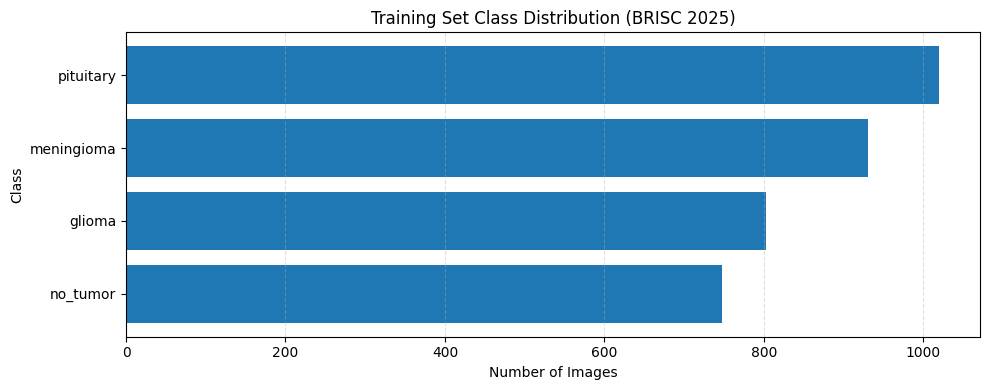

In [4]:
# Cell 4: Class Distribution Visualization

print("\n--- Class Distribution in the Training Set ---")

counts = train_df["label"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, max(4, 0.4 * len(counts))))
plt.barh(counts.index, counts.values)
plt.title("Training Set Class Distribution (BRISC 2025)")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.grid(True, axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



--- Displaying 5 Random Training Samples (Image / Mask / Overlay) ---


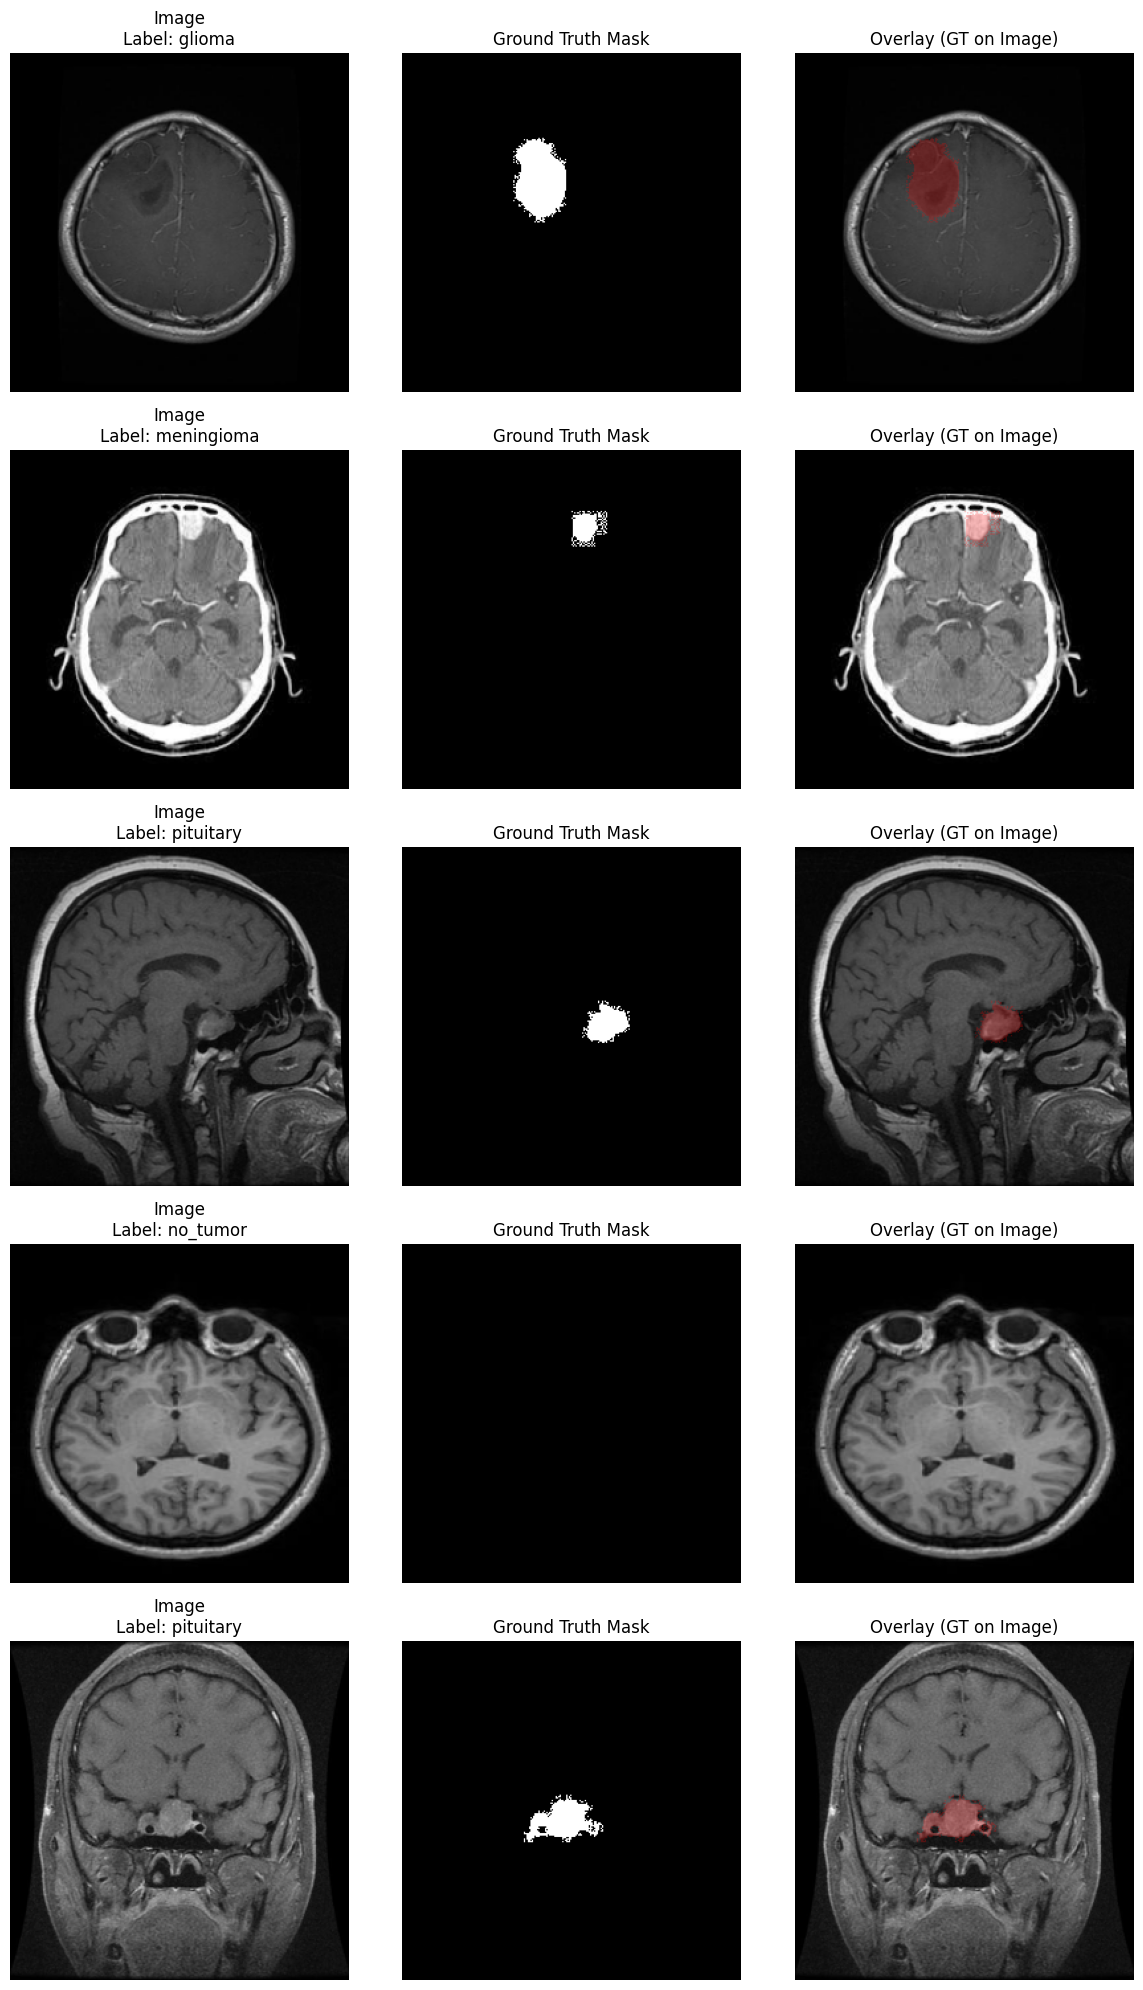

In [5]:
# Cell 5: Visualizing Sample Images and Masks

print("\n--- Displaying 5 Random Training Samples (Image / Mask / Overlay) ---")

def read_image_rgb(fp: str):
    img = cv2.imread(fp, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {fp}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def read_mask_binary(fp, target_hw):
    # If no mask path, return blank mask with same H,W
    if fp is None or (isinstance(fp, float) and np.isnan(fp)):
        return np.zeros(target_hw, dtype=np.uint8)

    m = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
    if m is None:
        return np.zeros(target_hw, dtype=np.uint8)

    m = (m > 0).astype(np.uint8)
    return m

def visualize_random_samples(df: pd.DataFrame, n: int = 5, display_size: int = 256):
    sample_df = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(len(sample_df)):
        row = sample_df.loc[i]
        img = read_image_rgb(row["image_path"])

        mask = read_mask_binary(row["mask_path"], target_hw=img.shape[:2])

        # Resize for consistent display
        img_d = cv2.resize(img, (display_size, display_size), interpolation=cv2.INTER_AREA)
        mask_d = cv2.resize(mask, (display_size, display_size), interpolation=cv2.INTER_NEAREST)

        # Overlay (red where mask==1)
        overlay = img_d.copy()
        overlay[mask_d == 1] = [255, 0, 0]
        overlay = cv2.addWeighted(img_d, 0.75, overlay, 0.25, 0)

        axes[i, 0].imshow(img_d)
        axes[i, 0].set_title(f"Image\nLabel: {row['label']}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_d, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay (GT on Image)")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_random_samples(train_df, n=5, display_size=256)

In [6]:
# Cell 6: Custom PyTorch Dataset

# CPU/memory-conscious image size (choose 128 or 224 as requested constraint)
IMG_SIZE = 128  # change to 224 if you prefer (slower on CPU, but closer to EfficientNet pretraining size)

# EfficientNet-B0 ImageNet normalization
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def build_transforms(is_train: bool):
    if is_train:
        return A.Compose(
            [
                A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_AREA),
                A.HorizontalFlip(p=0.5),
                A.ShiftScaleRotate(
                    shift_limit=0.03, scale_limit=0.05, rotate_limit=10,
                    border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0,
                    p=0.35
                ),
                A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=255.0),
                ToTensorV2(),
            ]
        )
    else:
        return A.Compose(
            [
                A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_AREA),
                A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=255.0),
                ToTensorV2(),
            ]
        )

class CustomDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        # Load image (OpenCV)
        img = cv2.imread(row["image_path"], cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {row['image_path']}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask (OpenCV). If missing => blank mask
        if pd.isna(row["mask_path"]):
            mask = np.zeros(img.shape[:2], dtype=np.uint8)
        else:
            mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
            if mask is None:
                mask = np.zeros(img.shape[:2], dtype=np.uint8)

        # binarize mask (0/1)
        mask = (mask > 0).astype(np.uint8)

        if self.transforms is not None:
            out = self.transforms(image=img, mask=mask)
            img_t = out["image"]            # float32 tensor, shape [3,H,W]
            mask_t = out["mask"]            # tensor, shape [H,W]
        else:
            # Fallback (shouldn't happen in this notebook)
            img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask_t = torch.from_numpy(mask).long()

        # Ensure mask is float and has channel dimension [1,H,W] for BCEWithLogitsLoss
        mask_t = (mask_t > 0).float().unsqueeze(0)

        # Classification label index (available for analysis; segmentation model uses mask)
        label_idx = torch.tensor(int(row["label_idx"]), dtype=torch.long)

        return img_t, mask_t, label_idx

train_tf = build_transforms(is_train=True)
val_tf   = build_transforms(is_train=False)

train_dataset = CustomDataset(train_df, transforms=train_tf)
val_dataset   = CustomDataset(val_df, transforms=val_tf)
test_dataset  = CustomDataset(test_df, transforms=val_tf)

print("Datasets ready:")
print("  Train:", len(train_dataset))
print("  Val:  ", len(val_dataset))
print("  Test: ", len(test_dataset))

Datasets ready:
  Train: 3500
  Val:   750
  Test:  750


In [7]:
# Cell 7: Model Architecture as LinkNet (EfficientNet-B0 Backbone) + Classification Head

print("\n--- Building LinkNet with an auxiliary classification head ---")

aux_params = {
    "pooling": "avg",
    "dropout": 0.30,
    "activation": None,
    "classes": len(label_map),  # multi-class classification head
}

model = smp.Linknet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,          # binary segmentation mask
    activation=None,
    aux_params=aux_params,
)

model = model.to(device)

print("Model created:", type(model).__name__)
print("Encoder:", "efficientnet-b0")
print("Segmentation output channels:", 1)
print("Classification classes:", len(label_map))
print("Device:", device)



--- Building LinkNet with an auxiliary classification head ---


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model created: Linknet
Encoder: efficientnet-b0
Segmentation output channels: 1
Classification classes: 4
Device: cuda


In [8]:
# Cell 8: Losses, Metrics, and Optimizer

print("\n--- Defining losses, metrics, and optimizer ---")

class DiceLoss(nn.Module):
    def __init__(self, eps: float = 1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        targets = targets.float()

        dims = (1, 2, 3)
        intersection = (probs * targets).sum(dims)
        denom = probs.sum(dims) + targets.sum(dims)
        dice = (2.0 * intersection + self.eps) / (denom + self.eps)

        return 1.0 - dice.mean()

def iou_score(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = (targets > 0.5).float()

    dims = (1, 2, 3)
    intersection = (preds * targets).sum(dims)
    union = (preds + targets - preds * targets).sum(dims)

    iou = (intersection + eps) / (union + eps)
    return iou.mean()

def dice_score(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = (targets > 0.5).float()

    dims = (1, 2, 3)
    intersection = (preds * targets).sum(dims)
    denom = preds.sum(dims) + targets.sum(dims)

    dice = (2.0 * intersection + eps) / (denom + eps)
    return dice.mean()

def classification_accuracy(class_logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    preds = class_logits.argmax(dim=1)
    return (preds == labels).float().mean()

seg_loss_bce = nn.BCEWithLogitsLoss()
seg_loss_dice = DiceLoss()

train_class_ids = train_df["label_idx"].astype(int).values
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_class_ids),
    y=train_class_ids,
)
class_weights = torch.tensor(class_weight_values, dtype=torch.float32, device=device)
class_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

SEG_LOSS_WEIGHT = 0.7
CLS_LOSS_WEIGHT = 0.3

def combined_loss(seg_logits: torch.Tensor, masks: torch.Tensor, class_logits: torch.Tensor, labels: torch.Tensor):
    bce = seg_loss_bce(seg_logits, masks)
    dice = seg_loss_dice(seg_logits, masks)
    seg_loss = 0.5 * bce + 0.5 * dice
    cls_loss = class_loss_fn(class_logits, labels)
    total = (SEG_LOSS_WEIGHT * seg_loss) + (CLS_LOSS_WEIGHT * cls_loss)
    return total, seg_loss, cls_loss

optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

print("Configured:")
print("  Segmentation loss : 0.5 * BCEWithLogits + 0.5 * DiceLoss")
print("  Classification loss:", class_loss_fn.__class__.__name__)
print(f"  Total loss        : {SEG_LOSS_WEIGHT:.1f} * SegLoss + {CLS_LOSS_WEIGHT:.1f} * ClsLoss")
print("  Metrics           : IoU, Dice, Classification Accuracy")
print("  Optimizer         : AdamW(lr=2e-4, weight_decay=1e-4)")



--- Defining losses, metrics, and optimizer ---
Configured:
  Segmentation loss : 0.5 * BCEWithLogits + 0.5 * DiceLoss
  Classification loss: CrossEntropyLoss
  Total loss        : 0.7 * SegLoss + 0.3 * ClsLoss
  Metrics           : IoU, Dice, Classification Accuracy
  Optimizer         : AdamW(lr=2e-4, weight_decay=1e-4)


In [9]:
# Cell 9: Training and Validation Loop

print("\n--- Starting training for multitask LinkNet (segmentation + classification) ---")

BATCH_SIZE = 4
NUM_WORKERS = 0 if os.name == "nt" else 2
PIN_MEMORY = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

# Internal split test loader is kept available for debugging / fallback.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

EPOCHS = 8

best_val_iou = -1.0
best_model_state = None

history = {
    "epoch": [],
    "train_loss": [],
    "train_seg_loss": [],
    "train_cls_loss": [],
    "train_iou": [],
    "train_acc": [],
    "val_loss": [],
    "val_seg_loss": [],
    "val_cls_loss": [],
    "val_iou": [],
    "val_acc": [],
}

for epoch in range(1, EPOCHS + 1):
    # -------------------- Train --------------------
    model.train()
    train_losses, train_seg_losses, train_cls_losses = [], [], []
    train_ious, train_accs = [], []

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    for images, masks, labels in train_pbar:
        images = images.to(device, non_blocking=PIN_MEMORY)
        masks = masks.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)

        seg_logits, class_logits = model(images)
        total_loss, seg_loss, cls_loss = combined_loss(seg_logits, masks, class_logits, labels)

        total_loss.backward()
        optimizer.step()

        with torch.no_grad():
            batch_iou = iou_score(seg_logits, masks).item()
            batch_acc = classification_accuracy(class_logits, labels).item()

        train_losses.append(total_loss.item())
        train_seg_losses.append(seg_loss.item())
        train_cls_losses.append(cls_loss.item())
        train_ious.append(batch_iou)
        train_accs.append(batch_acc)

        train_pbar.set_postfix(
            loss=float(np.mean(train_losses)),
            iou=float(np.mean(train_ious)),
            acc=float(np.mean(train_accs)),
        )

        del images, masks, labels, seg_logits, class_logits, total_loss, seg_loss, cls_loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

    avg_train_loss = float(np.mean(train_losses)) if train_losses else 0.0
    avg_train_seg_loss = float(np.mean(train_seg_losses)) if train_seg_losses else 0.0
    avg_train_cls_loss = float(np.mean(train_cls_losses)) if train_cls_losses else 0.0
    avg_train_iou = float(np.mean(train_ious)) if train_ious else 0.0
    avg_train_acc = float(np.mean(train_accs)) if train_accs else 0.0

    # -------------------- Validate --------------------
    model.eval()
    val_losses, val_seg_losses, val_cls_losses = [], [], []
    val_ious, val_accs = [], []

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)
        for images, masks, labels in val_pbar:
            images = images.to(device, non_blocking=PIN_MEMORY)
            masks = masks.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            seg_logits, class_logits = model(images)
            total_loss, seg_loss, cls_loss = combined_loss(seg_logits, masks, class_logits, labels)

            batch_iou = iou_score(seg_logits, masks).item()
            batch_acc = classification_accuracy(class_logits, labels).item()

            val_losses.append(total_loss.item())
            val_seg_losses.append(seg_loss.item())
            val_cls_losses.append(cls_loss.item())
            val_ious.append(batch_iou)
            val_accs.append(batch_acc)

            val_pbar.set_postfix(
                loss=float(np.mean(val_losses)),
                iou=float(np.mean(val_ious)),
                acc=float(np.mean(val_accs)),
            )

            del images, masks, labels, seg_logits, class_logits, total_loss, seg_loss, cls_loss

    avg_val_loss = float(np.mean(val_losses)) if val_losses else 0.0
    avg_val_seg_loss = float(np.mean(val_seg_losses)) if val_seg_losses else 0.0
    avg_val_cls_loss = float(np.mean(val_cls_losses)) if val_cls_losses else 0.0
    avg_val_iou = float(np.mean(val_ious)) if val_ious else 0.0
    avg_val_acc = float(np.mean(val_accs)) if val_accs else 0.0

    history["epoch"].append(epoch)
    history["train_loss"].append(avg_train_loss)
    history["train_seg_loss"].append(avg_train_seg_loss)
    history["train_cls_loss"].append(avg_train_cls_loss)
    history["train_iou"].append(avg_train_iou)
    history["train_acc"].append(avg_train_acc)
    history["val_loss"].append(avg_val_loss)
    history["val_seg_loss"].append(avg_val_seg_loss)
    history["val_cls_loss"].append(avg_val_cls_loss)
    history["val_iou"].append(avg_val_iou)
    history["val_acc"].append(avg_val_acc)

    print(
        f"Epoch {epoch} Summary | "
        f"Train Loss: {avg_train_loss:.4f} (Seg: {avg_train_seg_loss:.4f}, Cls: {avg_train_cls_loss:.4f}) | "
        f"Train IoU: {avg_train_iou:.4f}, Train Acc: {avg_train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} (Seg: {avg_val_seg_loss:.4f}, Cls: {avg_val_cls_loss:.4f}) | "
        f"Val IoU: {avg_val_iou:.4f}, Val Acc: {avg_val_acc:.4f}"
    )

    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best model stored in memory (best Val IoU: {best_val_iou:.4f})")

    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nBest model weights loaded (best Val IoU: {best_val_iou:.4f})")
else:
    print("\nWARNING: best_model_state is None; keeping last epoch weights.")



--- Starting training for multitask LinkNet (segmentation + classification) ---


Epoch 1/8 [Train]:   0%|          | 0/875 [00:00<?, ?it/s]

Epoch 1/8 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 Summary | Train Loss: 0.6073 (Seg: 0.5352, Cls: 0.7756) | Train IoU: 0.1739, Train Acc: 0.7437 | Val Loss: 0.4433 (Seg: 0.4888, Cls: 0.3371) | Val IoU: 0.2279, Val Acc: 0.9056
  -> New best model stored in memory (best Val IoU: 0.2279)


Epoch 2/8 [Train]:   0%|          | 0/875 [00:00<?, ?it/s]

...

Epoch 7/8 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 7 Summary | Train Loss: 0.2049 (Seg: 0.2378, Cls: 0.1279) | Train IoU: 0.5380, Train Acc: 0.9603 | Val Loss: 0.1966 (Seg: 0.2334, Cls: 0.1109) | Val IoU: 0.6056, Val Acc: 0.9721
  -> New best model stored in memory (best Val IoU: 0.6056)


Epoch 8/8 [Train]:   0%|          | 0/875 [00:00<?, ?it/s]

Epoch 8/8 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 8 Summary | Train Loss: 0.2069 (Seg: 0.2335, Cls: 0.1449) | Train IoU: 0.5476, Train Acc: 0.9574 | Val Loss: 0.1825 (Seg: 0.2286, Cls: 0.0749) | Val IoU: 0.5983, Val Acc: 0.9814

Best model weights loaded (best Val IoU: 0.6056)



--- Plotting training curves ---


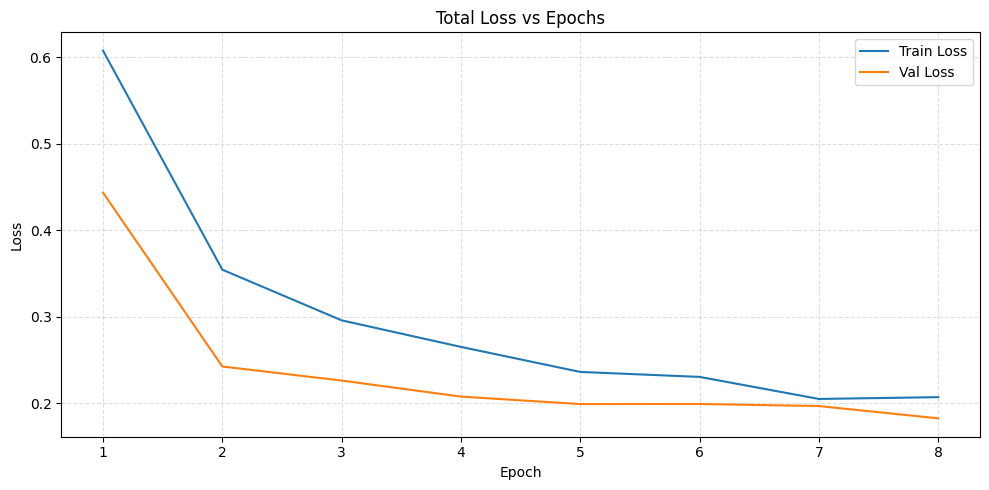

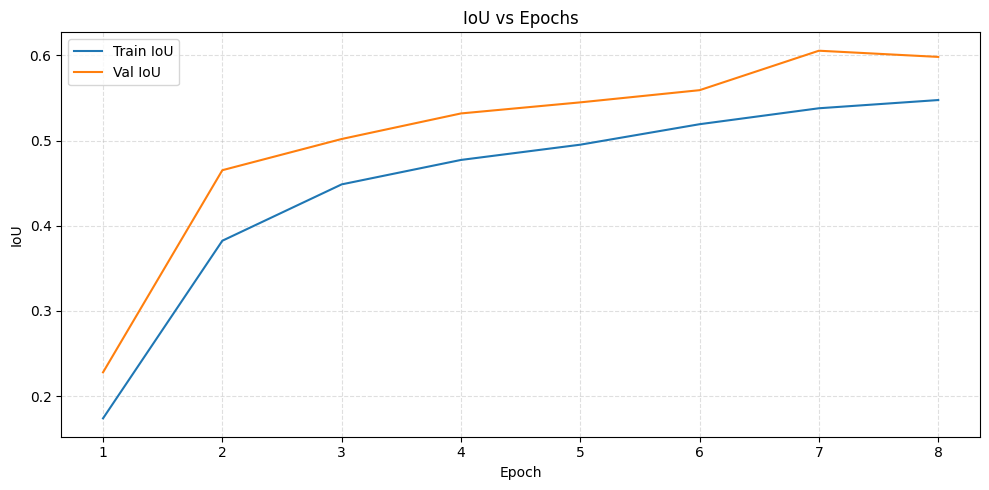

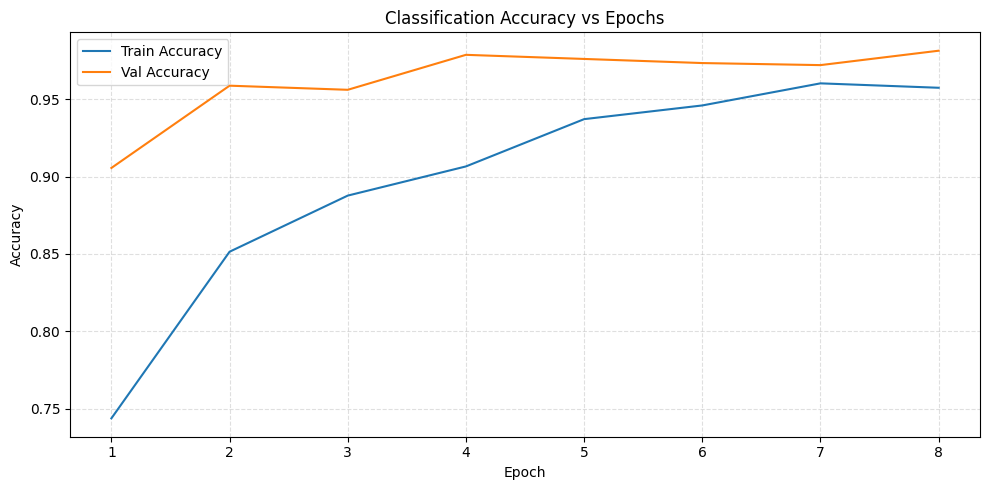

,epoch,train_loss,train_seg_loss,train_cls_loss,train_iou,train_acc,val_loss,val_seg_loss,val_cls_loss,val_iou,val_acc
0,1,0.607327,0.535200,0.775621,0.173884,0.743714,0.443299,0.488806,0.337117,0.227915,0.905585
1,2,0.354245,0.323312,0.426420,0.382444,0.851429,0.242372,0.281790,0.150396,0.465258,0.958777
2,3,0.295692,0.275406,0.343025,0.448608,0.887714,0.226115,0.258660,0.150176,0.501889,0.956117
3,4,0.265005,0.261187,0.273914,0.477300,0.906571,0.207582,0.251916,0.104135,0.531905,0.978723
4,5,0.236067,0.250861,0.201547,0.495215,0.937143,0.198928,0.248750,0.082675,0.544908,0.976064
5,6,0.230342,0.244009,0.198452,0.519264,0.946000,0.199063,0.241149,0.100862,0.559221,0.973404
6,7,0.204857,0.237849,0.127877,0.537980,0.960286,0.196647,0.233411,0.110863,0.605553,0.972074
7,8,0.206941,0.233510,0.144946,0.547624,0.957429,0.182451,0.228557,0.074870,0.598281,0.981383


In [10]:
# Cell 10: Plotting Training and Validation Curves

print("\n--- Plotting training curves ---")

history_df = pd.DataFrame(history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.title("Total Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_iou"], label="Train IoU")
plt.plot(history_df["epoch"], history_df["val_iou"], label="Val IoU")
plt.title("IoU vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Accuracy")
plt.title("Classification Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

display(history_df)



--- Visualizing predictions on a validation batch ---


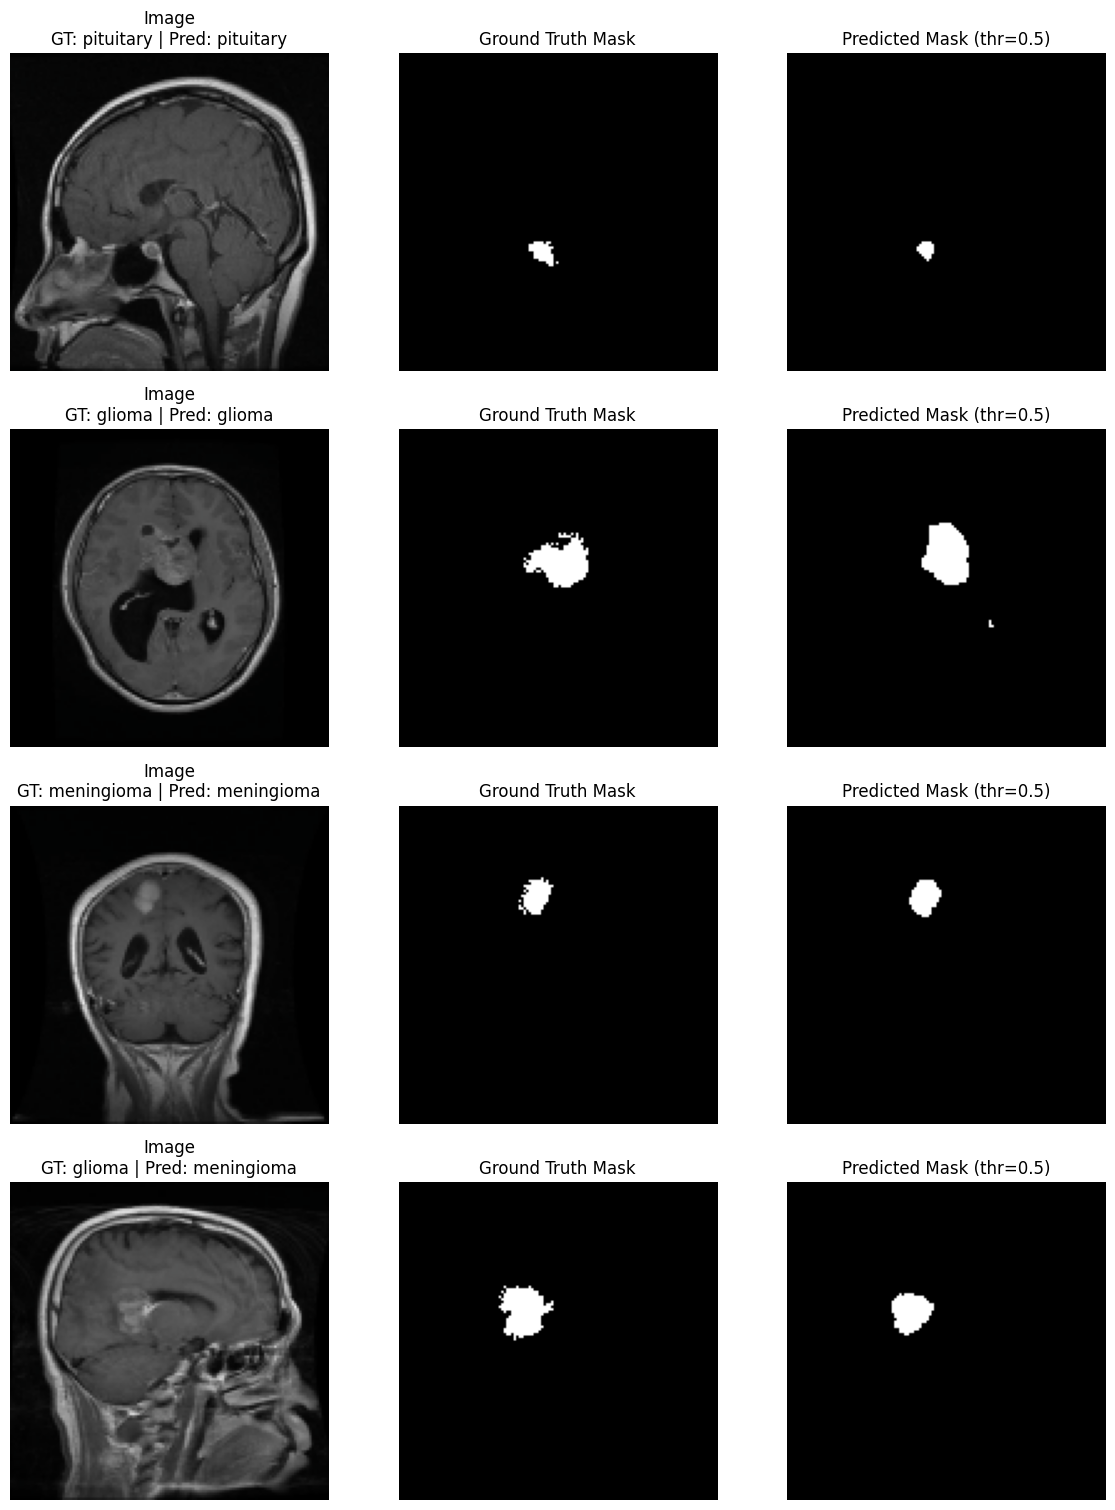

In [11]:
# Cell 11: Final Visualization

print("\n--- Visualizing predictions on a validation batch ---")

def denormalize_img(img_t: torch.Tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """
    img_t: [3, H, W], normalized
    returns float image [H, W, 3] in [0, 1]
    """
    img = img_t.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std).reshape(1, 1, 3) + np.array(mean).reshape(1, 1, 3)
    return np.clip(img, 0.0, 1.0)

idx_to_label = {v: k for k, v in label_map.items()}

model.eval()

images, masks, labels = next(iter(val_loader))
images = images.to(device)
masks = masks.to(device)
labels = labels.to(device)

with torch.no_grad():
    seg_logits, class_logits = model(images)
    probs = torch.sigmoid(seg_logits)
    preds = (probs > 0.5).float()
    class_preds = class_logits.argmax(dim=1)

num_show = min(4, images.shape[0])

fig, axes = plt.subplots(num_show, 3, figsize=(12, 3.8 * num_show))
if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_show):
    img_vis = denormalize_img(images[i])
    gt_mask = masks[i, 0].detach().cpu().numpy()
    pred_mask = preds[i, 0].detach().cpu().numpy()

    gt_label_name = idx_to_label[int(labels[i].item())]
    pred_label_name = idx_to_label[int(class_preds[i].item())]

    axes[i, 0].imshow(img_vis)
    axes[i, 0].set_title(f"Image\nGT: {gt_label_name} | Pred: {pred_label_name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt_mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].set_title("Predicted Mask (thr=0.5)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

del images, masks, labels, seg_logits, class_logits, probs, preds, class_preds
gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()



--- Test set evaluation (best weights) ---
Using official Kaggle test set with 1000 samples.


Testing:   0%|          | 0/250 [00:00<?, ?it/s]

Final Test Loss     : 0.1907
  - Segmentation    : 0.2075
  - Classification  : 0.1514
Final Test IoU      : 0.6135
Final Test Dice     : 0.7166
Final Test Accuracy : 0.9610 (96.10%)

--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       254
  meningioma       0.96      0.92      0.94       306
    no_tumor       0.89      1.00      0.94       140
   pituitary       0.98      0.99      0.98       300

    accuracy                           0.96      1000
   macro avg       0.95      0.97      0.96      1000
weighted avg       0.96      0.96      0.96      1000


--- Confusion Matrix ---


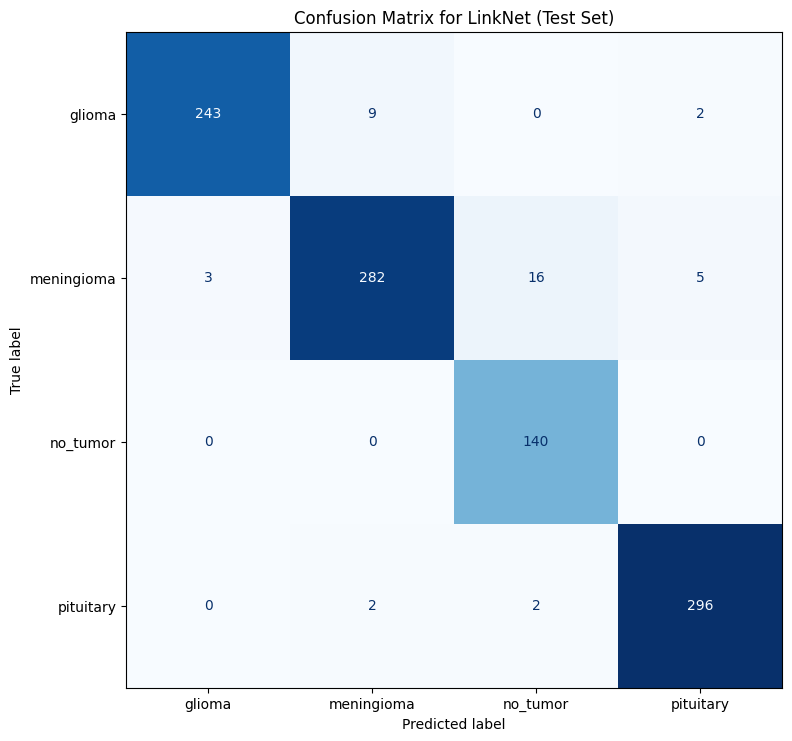

In [12]:
# Cell 12: Evaluation for Test Set

print("\n--- Test set evaluation (best weights) ---")

if best_model_state is not None:
    model.load_state_dict(best_model_state)

def build_official_test_dataframe(base_path: str, label_map: dict) -> pd.DataFrame:
    classification_test_path = os.path.join(base_path, "classification_task", "test")
    segmentation_test_path = os.path.join(base_path, "segmentation_task", "test")

    if not os.path.isdir(classification_test_path):
        return pd.DataFrame()

    # 1) Classification image table
    image_rows = []
    label_folders = [
        d for d in os.listdir(classification_test_path)
        if os.path.isdir(os.path.join(classification_test_path, d))
    ]
    label_folders = sorted(label_folders)

    for label_name in label_folders:
        label_dir = os.path.join(classification_test_path, label_name)
        for fp in list_image_files(label_dir):
            image_rows.append(
                {
                    "image_path": fp,
                    "label": label_name,
                    "image_id": stem_id(fp),
                }
            )

    if not image_rows:
        return pd.DataFrame()

    master_test_df = pd.DataFrame(image_rows)

    # 2) Mask table
    seg_images_path = os.path.join(segmentation_test_path, "images")
    seg_masks_path = os.path.join(segmentation_test_path, "masks")

    if os.path.isdir(seg_images_path) and os.path.isdir(seg_masks_path):
        seg_image_files = list_image_files(seg_images_path)
        seg_mask_files = list_image_files(seg_masks_path)

        mask_map = {}
        for mfp in seg_mask_files:
            mid = normalize_mask_id(stem_id(mfp))
            if mid not in mask_map:
                mask_map[mid] = mfp

        mask_rows = []
        for ifp in seg_image_files:
            iid = stem_id(ifp)
            if iid in mask_map:
                mask_rows.append((iid, mask_map[iid]))

        mask_df = pd.DataFrame(mask_rows, columns=["image_id", "mask_path"])
    else:
        mask_df = pd.DataFrame(columns=["image_id", "mask_path"])

    final_test_df = pd.merge(master_test_df, mask_df, on="image_id", how="left")
    final_test_df["label_idx"] = final_test_df["label"].map(label_map)

    if final_test_df["label_idx"].isna().any():
        unknown_labels = sorted(final_test_df.loc[final_test_df["label_idx"].isna(), "label"].unique().tolist())
        print("Warning: dropping samples with labels missing from label_map:", unknown_labels)
        final_test_df = final_test_df.dropna(subset=["label_idx"]).copy()

    final_test_df["label_idx"] = final_test_df["label_idx"].astype(int)
    final_test_df["tumor_present"] = (~final_test_df["label"].str.lower().isin(
        {"no_tumor", "no-tumor", "no tumor", "healthy", "normal", "nt"}
    )).astype(int)

    return final_test_df.reset_index(drop=True)

official_test_df = build_official_test_dataframe(base_path, label_map)

if len(official_test_df) > 0:
    print(f"Using official Kaggle test set with {len(official_test_df)} samples.")
    test_df = official_test_df.copy()
else:
    print("Official Kaggle test set was not found. Falling back to the internal split test set.")
    test_df = test_df.reset_index(drop=True)

test_dataset = CustomDataset(test_df, transforms=val_tf)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

model.eval()

test_losses = []
test_seg_losses = []
test_cls_losses = []
test_ious = []
test_dices = []

all_class_preds = []
all_class_labels = []
all_class_probs = []

with torch.no_grad():
    for images, masks, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=PIN_MEMORY)
        masks = masks.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)

        seg_logits, class_logits = model(images)
        total_loss, seg_loss, cls_loss = combined_loss(seg_logits, masks, class_logits, labels)

        test_losses.append(total_loss.item())
        test_seg_losses.append(seg_loss.item())
        test_cls_losses.append(cls_loss.item())
        test_ious.append(iou_score(seg_logits, masks).item())
        test_dices.append(dice_score(seg_logits, masks).item())

        probs = torch.softmax(class_logits, dim=1)
        preds = probs.argmax(dim=1)

        all_class_preds.extend(preds.cpu().numpy().tolist())
        all_class_labels.extend(labels.cpu().numpy().tolist())
        all_class_probs.extend(probs.cpu().numpy().tolist())

avg_test_loss = float(np.mean(test_losses)) if test_losses else 0.0
avg_test_seg_loss = float(np.mean(test_seg_losses)) if test_seg_losses else 0.0
avg_test_cls_loss = float(np.mean(test_cls_losses)) if test_cls_losses else 0.0
avg_test_iou = float(np.mean(test_ious)) if test_ious else 0.0
avg_test_dice = float(np.mean(test_dices)) if test_dices else 0.0

all_class_preds = np.array(all_class_preds, dtype=np.int64)
all_class_labels = np.array(all_class_labels, dtype=np.int64)
all_class_probs = np.array(all_class_probs, dtype=np.float32)

test_accuracy = float((all_class_preds == all_class_labels).mean()) if len(all_class_labels) else 0.0

print(f"Final Test Loss     : {avg_test_loss:.4f}")
print(f"  - Segmentation    : {avg_test_seg_loss:.4f}")
print(f"  - Classification  : {avg_test_cls_loss:.4f}")
print(f"Final Test IoU      : {avg_test_iou:.4f}")
print(f"Final Test Dice     : {avg_test_dice:.4f}")
print(f"Final Test Accuracy : {test_accuracy:.4f} ({test_accuracy:.2%})")

class_names = [name for name, idx in sorted(label_map.items(), key=lambda item: item[1])]
class_id_list = list(range(len(class_names)))

print("\n--- Classification Report ---")
print(
    classification_report(
        all_class_labels,
        all_class_preds,
        labels=class_id_list,
        target_names=class_names,
        zero_division=0,
    )
)

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_class_labels, all_class_preds, labels=class_id_list)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix for LinkNet (Test Set)")
plt.tight_layout()
plt.show()



--- ROC / AUC for LinkNet classification head ---


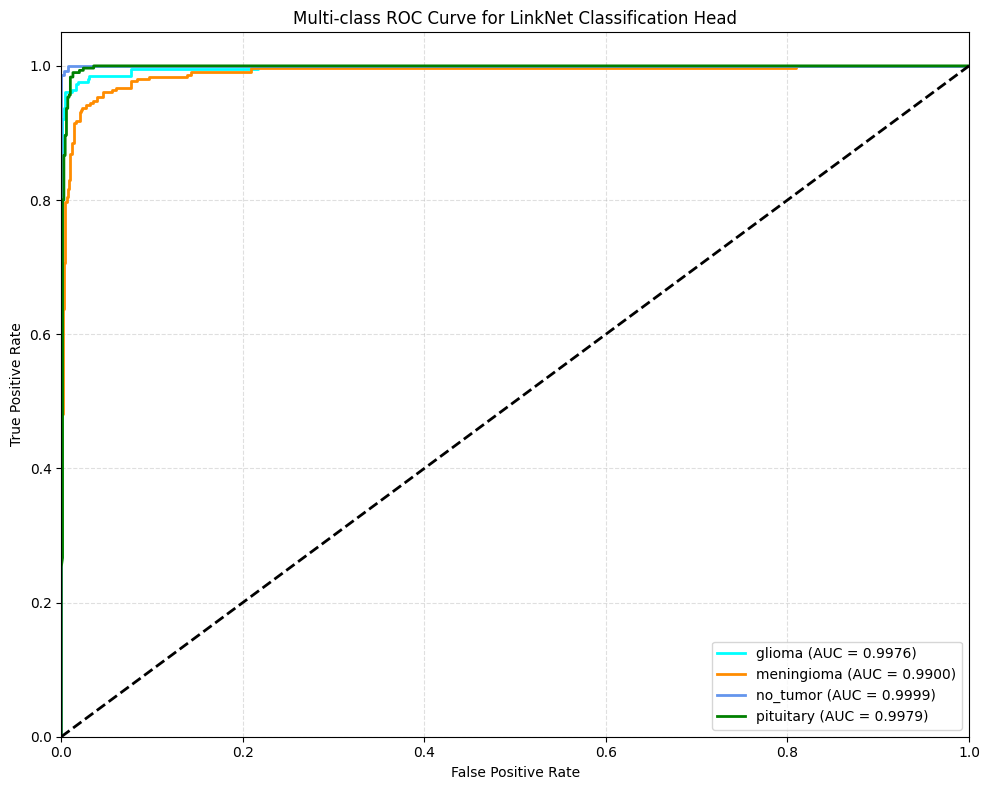


AUC scores by class:
  glioma: 0.9976
  meningioma: 0.9900
  no_tumor: 0.9999
  pituitary: 0.9979


In [13]:
# Cell 13: Generating ROC Curve and AUC for Classification

print("\n--- ROC / AUC for LinkNet classification head ---")

if len(all_class_labels) == 0 or len(all_class_probs) == 0:
    raise RuntimeError("Classification probabilities are missing. Run the test evaluation cell first.")

y_true = np.array(all_class_labels, dtype=np.int64)
y_score = np.array(all_class_probs, dtype=np.float32)

n_classes = len(label_map)
class_ids = list(range(n_classes))
class_names = [name for name, idx in sorted(label_map.items(), key=lambda item: item[1])]

y_true_bin = label_binarize(y_true, classes=class_ids)

# sklearn returns a single column for binary problems; convert it to two columns
if n_classes == 2 and y_true_bin.shape[1] == 1:
    y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

plt.figure(figsize=(10, 8))
colors = cycle(["aqua", "darkorange", "cornflowerblue", "green", "purple", "red", "brown", "olive"])
valid_curve_count = 0
roc_auc_scores = {}

for i, color in zip(range(n_classes), colors):
    positives = y_true_bin[:, i].sum()
    negatives = len(y_true_bin[:, i]) - positives

    if positives == 0 or negatives == 0:
        print(f"Skipping ROC for class '{class_names[i]}' because the evaluation set lacks positive or negative examples.")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc_value = auc(fpr, tpr)
    roc_auc_scores[class_names[i]] = roc_auc_value
    valid_curve_count += 1

    plt.plot(
        fpr,
        tpr,
        lw=2,
        color=color,
        label=f"{class_names[i]} (AUC = {roc_auc_value:.4f})",
    )

if valid_curve_count == 0:
    print("ROC curves could not be plotted because the current evaluation set does not contain enough class diversity.")
else:
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC Curve for LinkNet Classification Head")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    print("\nAUC scores by class:")
    for class_name, auc_value in roc_auc_scores.items():
        print(f"  {class_name}: {auc_value:.4f}")



--- Segmenting 10 random test images (Image / GT / Prediction) ---


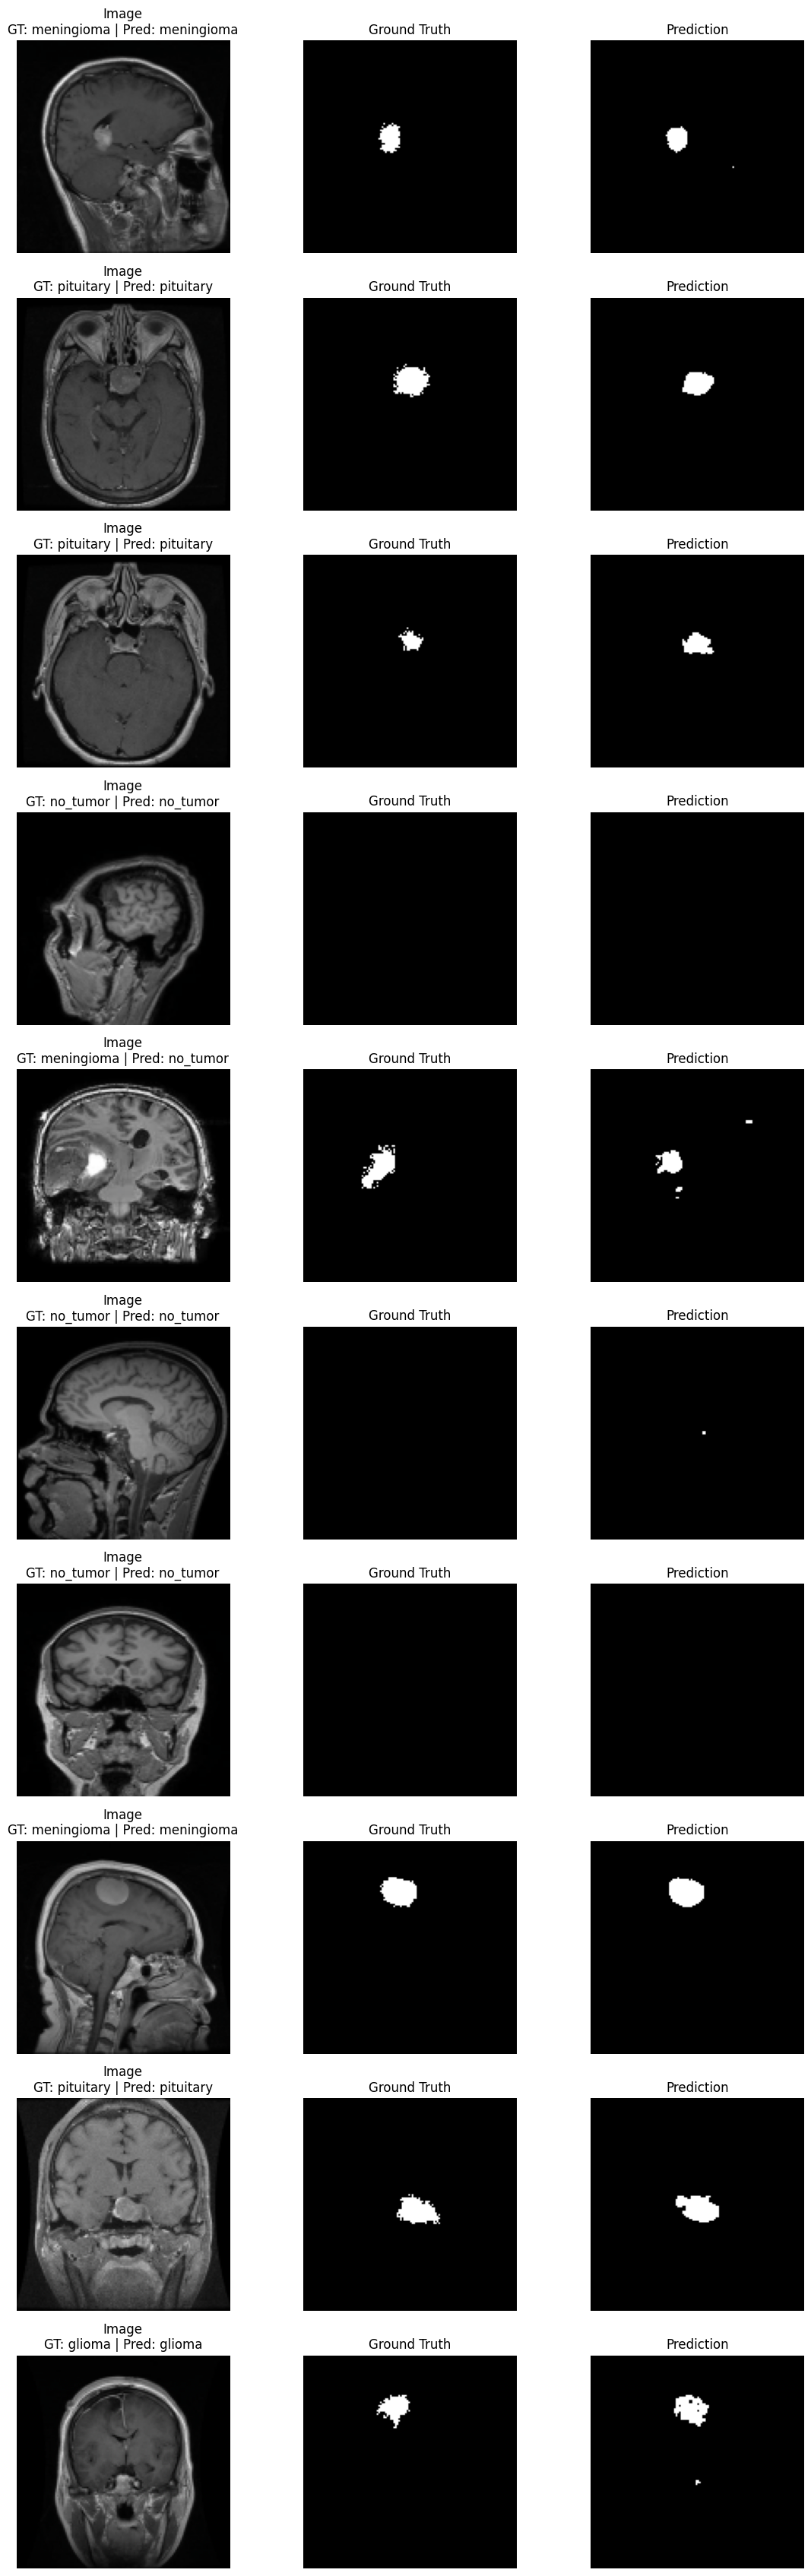

In [14]:
# Cell 14: Segmenting 10 Random Images from the Test Set (Step-by-Step)

print("\n--- Segmenting 10 random test images (Image / GT / Prediction) ---")

model.eval()

num_samples_to_segment = min(10, len(test_df))
random_indices = np.random.RandomState(SEED).choice(len(test_df), size=num_samples_to_segment, replace=False)

def tensor_to_mask_np(mask_t: torch.Tensor):
    if mask_t.ndim == 3:
        mask_t = mask_t[0]
    return mask_t.detach().cpu().numpy()

idx_to_label = {v: k for k, v in label_map.items()}

fig, axes = plt.subplots(num_samples_to_segment, 3, figsize=(12, 3.4 * num_samples_to_segment))
if num_samples_to_segment == 1:
    axes = np.expand_dims(axes, axis=0)

with torch.no_grad():
    for i, df_idx in enumerate(random_indices):
        img_t, gt_mask_t, gt_label_t = test_dataset[df_idx]
        img_in = img_t.unsqueeze(0).to(device)
        gt_in = gt_mask_t.unsqueeze(0).to(device)

        seg_logits, class_logits = model(img_in)
        prob = torch.sigmoid(seg_logits)[0, 0]
        pred_mask = (prob > 0.5).float().cpu().numpy()
        pred_label = int(class_logits.argmax(dim=1).item())

        img_vis = denormalize_img(img_t)
        gt_mask = tensor_to_mask_np(gt_mask_t)
        gt_label = int(gt_label_t.item())

        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title(f"Image\nGT: {idx_to_label[gt_label]} | Pred: {idx_to_label[pred_label]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()


In [15]:
# Cell 15: Initialize lists to store results & Create a DataFrame

print("\n--- Computing per-image IoU and classification correctness on the test set ---")

image_path_list = []
mask_path_list = []
true_label_list = []
pred_label_list = []
cls_correct_list = []
iou_score_list = []

idx_to_label = {v: k for k, v in label_map.items()}

model.eval()

for idx in tqdm(range(len(test_df)), desc="Per-image metrics"):
    row = test_df.iloc[idx]

    img_t, gt_mask_t, gt_label_t = test_dataset[idx]
    img_in = img_t.unsqueeze(0).to(device)
    gt_in = gt_mask_t.unsqueeze(0).to(device)

    with torch.no_grad():
        seg_logits, class_logits = model(img_in)
        iou_val = float(iou_score(seg_logits, gt_in).item())
        pred_class = int(class_logits.argmax(dim=1).item())

    true_class = int(gt_label_t.item())

    image_path_list.append(row["image_path"])
    mask_path_list.append(None if pd.isna(row["mask_path"]) else row["mask_path"])
    true_label_list.append(idx_to_label[true_class])
    pred_label_list.append(idx_to_label[pred_class])
    cls_correct_list.append(int(pred_class == true_class))
    iou_score_list.append(iou_val)

results_df = pd.DataFrame({
    "image_path": image_path_list,
    "mask_path": mask_path_list,
    "true_label": true_label_list,
    "pred_label": pred_label_list,
    "cls_correct": cls_correct_list,
    "iou_score": iou_score_list,
})

print("results_df created:")
display(results_df.head())

print("\nPer-image IoU summary:")
display(results_df["iou_score"].describe())

print("\nPer-image classification correctness summary:")
display(results_df["cls_correct"].value_counts().rename(index={1: "Correct", 0: "Incorrect"}))



--- Computing per-image IoU and classification correctness on the test set ---


Per-image metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

results_df created:


,image_path,mask_path,true_label,pred_label,cls_correct,iou_score
0,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,glioma,1,1.859504e-02
1,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,glioma,1,5.116279e-01
2,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,glioma,1,4.504673e-01
3,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,pituitary,0,9.868421e-02
4,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,glioma,1,9.900990e-10



Per-image IoU summary:


count    1.000000e+03
mean     6.135135e-01
std      2.690831e-01
min      1.432665e-10
25%      4.904715e-01
50%      6.713862e-01
75%      7.962631e-01
max      1.000000e+00
Name: iou_score, dtype: float64


Per-image classification correctness summary:


cls_correct
Correct      961
Incorrect     39
Name: count, dtype: int64


--- Visualizing worst segmentations (lowest IoU) ---


,image_path,mask_path,true_label,pred_label,cls_correct,iou_score
0,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,glioma,1,1.432665e-10
1,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,glioma,1,2.188184e-10
2,/kaggle/input/datasets/briscdataset/brisc2025/...,None,no_tumor,no_tumor,1,3.533569e-10
3,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,pituitary,0,3.584229e-10
4,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...,glioma,glioma,1,3.623188e-10


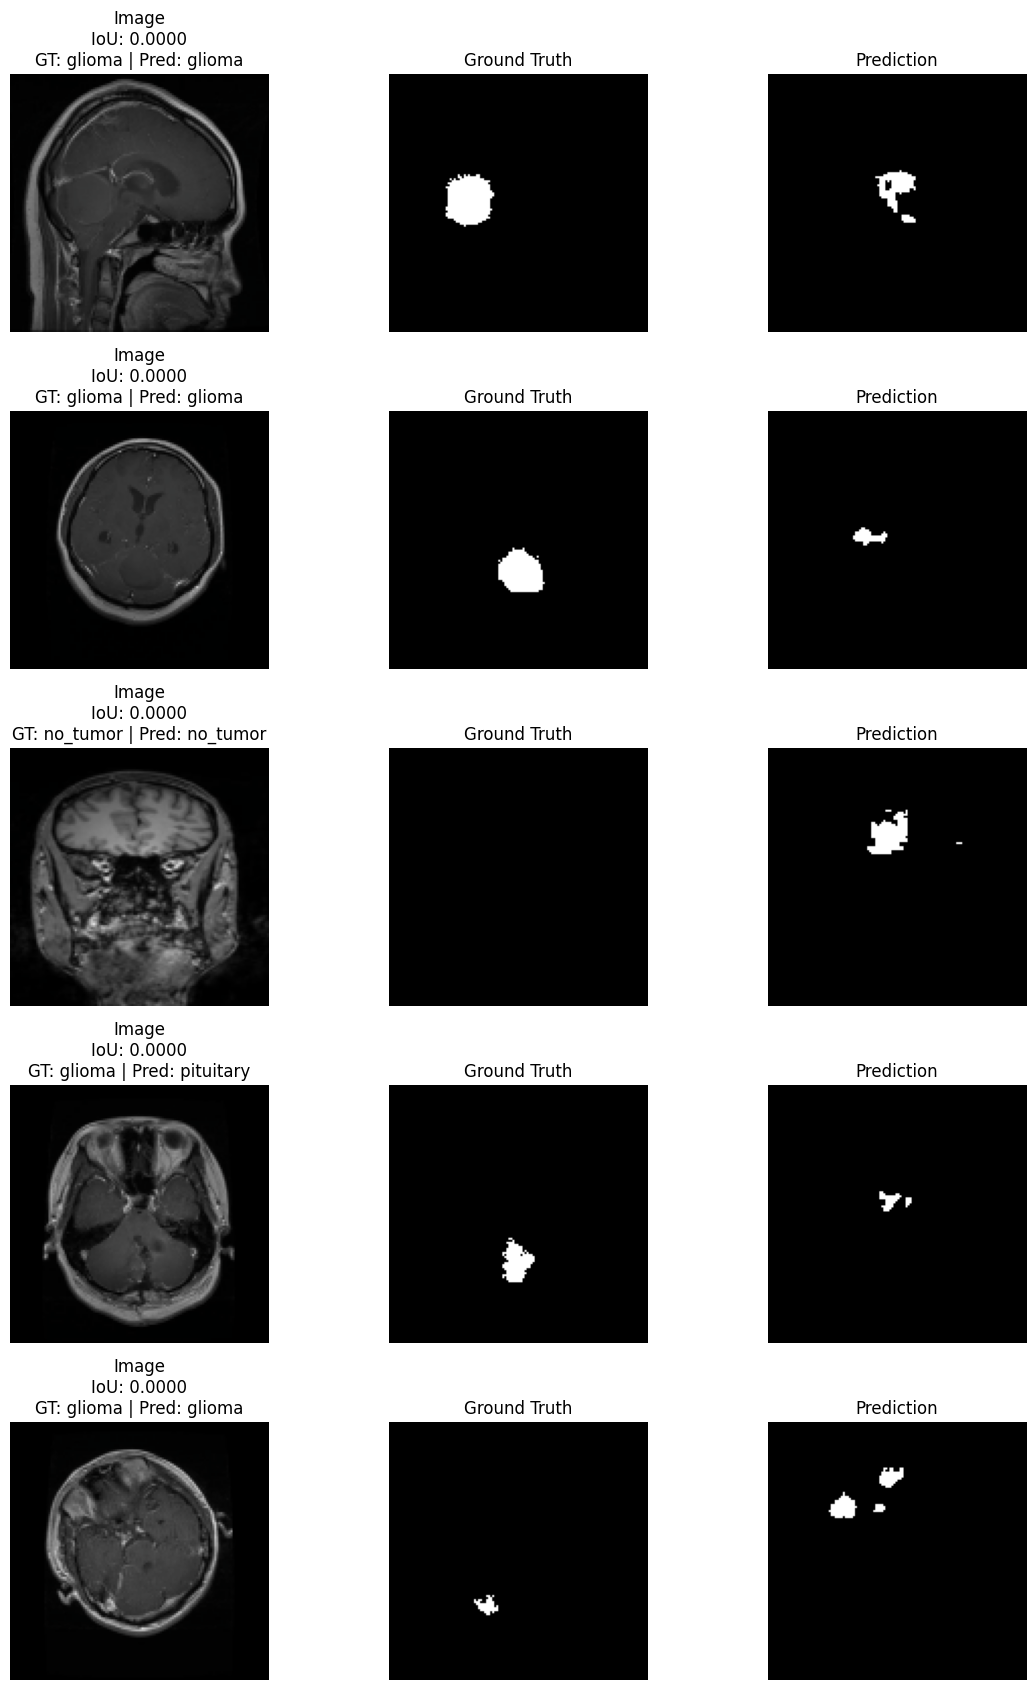

In [16]:
# Cell 16: Visualize the top N worst segmentations

print("\n--- Visualizing worst segmentations (lowest IoU) ---")

N_WORST = min(5, len(results_df))
worst_df = results_df.sort_values("iou_score", ascending=True).head(N_WORST).reset_index(drop=True)
display(worst_df)

fig, axes = plt.subplots(N_WORST, 3, figsize=(12, 3.4 * N_WORST))
if N_WORST == 1:
    axes = np.expand_dims(axes, axis=0)

model.eval()

with torch.no_grad():
    for i in range(N_WORST):
        img_path = worst_df.loc[i, "image_path"]
        df_idx = int(test_df.index[test_df["image_path"] == img_path][0])

        img_t, gt_mask_t, gt_label_t = test_dataset[df_idx]
        img_in = img_t.unsqueeze(0).to(device)

        seg_logits, class_logits = model(img_in)
        prob = torch.sigmoid(seg_logits)[0, 0]
        pred_mask = (prob > 0.5).float().cpu().numpy()

        img_vis = denormalize_img(img_t)
        gt_mask = tensor_to_mask_np(gt_mask_t)
        pred_class = int(class_logits.argmax(dim=1).item())

        axes[i, 0].imshow(img_vis)
        axes[i, 0].set_title(
            f"Image\nIoU: {worst_df.loc[i, 'iou_score']:.4f}\n"
            f"GT: {worst_df.loc[i, 'true_label']} | Pred: {worst_df.loc[i, 'pred_label']}"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()


In [17]:
# Cell 17: Save model directly to Kaggle working directory

print("\n--- Saving best LinkNet multitask checkpoint to /kaggle/working ---")

if best_model_state is not None:
    model.load_state_dict(best_model_state)

save_path = "/kaggle/working/best_linknet_multitask.pth"
checkpoint = {
    "model_state_dict": model.state_dict(),
    "label_map": label_map,
    "img_size": IMG_SIZE,
    "encoder_name": "efficientnet-b0",
    "segmentation_classes": 1,
    "classification_classes": len(label_map),
    "best_val_iou": best_val_iou,
}
torch.save(checkpoint, save_path)

print(f"✅ Best LinkNet multitask checkpoint saved at: {save_path}")
print("You can download it from the Kaggle Notebook 'Output' tab after the run completes.")



--- Saving best LinkNet multitask checkpoint to /kaggle/working ---
✅ Best LinkNet multitask checkpoint saved at: /kaggle/working/best_linknet_multitask.pth
You can download it from the Kaggle Notebook 'Output' tab after the run completes.
